# Survival Analysis with Progenetix CNV Data

In this notebook, we build a simple survival analysis example using Progenetix data.

The basic workflow:

1. retrieve sample-level metadata,
2. retreive individual-level data with survival information,
3. retrieve sample-level CNV records,
4. convert CNV records into simple gene-level features,
5. and apply two standard survival analysis methods.

We will use:

- **Kaplan–Meier curves** to compare survival between two groups,
- and a **Cox proportional hazards model** to estimate how a CNV-derived feature is associated with hazard.



choose cancer genes we like, put in the models to study hazard rates
also look ar other things related to survival (race, sex, etc.)
try different ways to plot data

## Environment Setup

```bash
conda install -c conda-forge scikit-survival
pip install scikit-survival

In [1]:
import requests
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

from tqdm.auto import tqdm

from sksurv.util import Surv
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

/home/emily/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download sample metadata from Progenetix

We begin with the Progenetix `sampletable` service.

This service returns sample annotations in tabular form and supports query filters.
For example, the Progenetix documentation shows that TCGA samples can be retrieved with:

- `filters=pgx:cohort-TCGAcancers`

and that:

- `limit=0` means no result limit.


In [10]:
# -----------------------------
# Cohort definition
# -----------------------------
TARGET_TCGA_PROJECT = "pgx:TCGA-BRCA"   

# -----------------------------
# Progenetix sampletable endpoint
# -----------------------------
SAMPLETABLE_URL = "https://progenetix.org/services/sampletable/"

In [11]:
def fetch_sampletable(filters, limit=0, timeout=120):
    # Download a Progenetix sample table as a pandas DataFrame.
    params = {
        "filters": filters,
        "limit": limit,
    }

    response = requests.get(SAMPLETABLE_URL, params=params, timeout=timeout)
    response.raise_for_status()

    print("Status:", response.status_code)
    print("Final URL:", response.url)
    print("Content-Type:", response.headers.get("Content-Type"))

    text = response.text
    df = pd.read_csv(io.StringIO(text), sep="\t")
    return df

In [12]:
sample_table_df = fetch_sampletable(filters=TARGET_TCGA_PROJECT, limit=0)

print("Shape:", sample_table_df.shape)
print("Columns:")
print(sample_table_df.columns.tolist())
sample_table_df.head()

Status: 200
Final URL: https://progenetix.org/services/sampletable/?filters=pgx%3ATCGA-BRCA&limit=0
Content-Type: text/tsv
Shape: (2219, 42)
Columns:
['biosample_id', 'individual_id', 'biosample_name', 'notes', 'histological_diagnosis_id', 'histological_diagnosis_label', 'pathological_stage_id', 'pathological_stage_label', 'biosample_status_id', 'biosample_status_label', 'sample_origin_type_id', 'sample_origin_type_label', 'sampled_tissue_id', 'sampled_tissue_label', 'tnm', 'tumor_grade_id', 'tumor_grade_label', 'age_iso', 'age_days', 'icdo_morphology_id', 'icdo_morphology_label', 'icdo_topography_id', 'icdo_topography_label', 'pubmed_id', 'pubmed_label', 'cellosaurus_id', 'cellosaurus_label', 'cbioportal_id', 'cbioportal_label', 'tcgaproject_id', 'tcgaproject_label', 'cohorts', 'geoprov_id', 'geoprov_city', 'geoprov_country', 'geoprov_iso_alpha3', 'geoprov_long_lat', 'followup_days', 'sex_id', 'sex_label', 'group_id', 'group_label']


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,biosample_status_id,biosample_status_label,...,geoprov_id,geoprov_city,geoprov_country,geoprov_iso_alpha3,geoprov_long_lat,followup_days,sex_id,sex_label,group_id,group_label
0,pgxbs-kftvi3zb,pgxind-kftx3mv9,19791868-631f-4d60-8893-518d741a39ef,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27977,Stage IIIA,EFO:0009654,reference sample,...,chapelhill::unitedstates::-79.05584::35.9132,Chapel Hill,United States,USA,-79.05584::35.9132,NaN,NaN,NaN,NaN,NaN
1,pgxbs-kftvhil5,pgxind-kftx3gi9,7c959418-dc26-485d-a824-4906998af2c2,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,EFO:0009654,reference sample,...,chapelhill::unitedstates::-79.05584::35.9132,Chapel Hill,United States,USA,-79.05584::35.9132,NaN,NaN,NaN,NaN,NaN
2,pgxbs-kftvhnny,pgxind-kftx3m7z,67d804d7-b6a5-4a70-92cd-f93195d928a4,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27968,Stage IIB,EFO:0009656,neoplastic sample,...,chapelhill::unitedstates::-79.05584::35.9132,Chapel Hill,United States,USA,-79.05584::35.9132,NaN,NaN,NaN,NaN,NaN
3,pgxbs-kftvhq2j,pgxind-kftx3oeo,1d6cd463-d7b3-4e05-b0e5-3a578ec2cfdd,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27966,Stage I,EFO:0009654,reference sample,...,chapelhill::unitedstates::-79.05584::35.9132,Chapel Hill,United States,USA,-79.05584::35.9132,NaN,NaN,NaN,NaN,NaN
4,pgxbs-kftvhkb9,pgxind-kftx3fa9,77986d47-e916-41a3-933a-85abd508050e,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,EFO:0009654,reference sample,...,chapelhill::unitedstates::-79.05584::35.9132,Chapel Hill,United States,USA,-79.05584::35.9132,NaN,NaN,NaN,NaN,NaN


In [13]:
# Columns we want to keep from the sample table
BIOSAMPLE_COLUMNS = [
    "biosample_id",
    "individual_id",
    "biosample_name",
    "notes",
    "histological_diagnosis_id",
    "histological_diagnosis_label",
    "pathological_stage_id",
    "pathological_stage_label",
    "sample_origin_type_id",
    "sample_origin_type_label",
    "sampled_tissue_id",
    "sampled_tissue_label",
    "tcgaproject_id",
    "tcgaproject_label",
    "icdo_morphology_id",
    "icdo_topography_id",
    "icdo_topography_label",
]

BIOSAMPLE_COLUMNS = [c for c in BIOSAMPLE_COLUMNS if c in sample_table_df.columns]

biosample_df = sample_table_df[BIOSAMPLE_COLUMNS].copy()

print("Biosample-level metadata shape:", biosample_df.shape)
biosample_df.head()

Biosample-level metadata shape: (2219, 17)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,sampled_tissue_id,sampled_tissue_label,tcgaproject_id,tcgaproject_label,icdo_morphology_id,icdo_topography_id,icdo_topography_label
0,pgxbs-kftvi3zb,pgxind-kftx3mv9,19791868-631f-4d60-8893-518d741a39ef,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-BRCA,Breast invasive carcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
1,pgxbs-kftvhil5,pgxind-kftx3gi9,7c959418-dc26-485d-a824-4906998af2c2,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-BRCA,Breast invasive carcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
2,pgxbs-kftvhnny,pgxind-kftx3m7z,67d804d7-b6a5-4a70-92cd-f93195d928a4,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,UBERON:0000310,breast,pgx:TCGA-BRCA,Breast invasive carcinoma,pgx:icdom-85003,pgx:icdot-C50.9,"Breast, NOS"
3,pgxbs-kftvhq2j,pgxind-kftx3oeo,1d6cd463-d7b3-4e05-b0e5-3a578ec2cfdd,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-BRCA,Breast invasive carcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood
4,pgxbs-kftvhkb9,pgxind-kftx3fa9,77986d47-e916-41a3-933a-85abd508050e,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,UBERON:0000178,blood,pgx:TCGA-BRCA,Breast invasive carcinoma,pgx:icdom-00000,pgx:icdot-C42.0,Blood


## Build survival metadata by combining biosample- and individual-level information

The Progenetix sample table is useful for cohort selection and biosample-level metadata, but survival-related information is not always available there.

In our case, each biosample is linked to an `individual_id`.  
We therefore use a two-step strategy:

1. retrieve **biosample-level metadata** from the Progenetix sample table,
2. retrieve **individual-level follow-up metadata** from the Progenetix individual endpoint,
3. and merge the two through `individual_id`.

This is important because survival analysis requires at least:

- a follow-up time,
- and an event indicator.

These fields are available in the individual-level record.

In the Progenetix data model, one individual may have more than one biosample.  
Therefore, after merging biosample- and individual-level metadata, we also need to decide how to handle the one-to-many relationship before building a survival model.

In [14]:
individual_ids = (
    biosample_df["individual_id"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

print("Number of unique individuals:", len(individual_ids))
print(individual_ids[:10])

Number of unique individuals: 1096
['pgxind-kftx3mv9', 'pgxind-kftx3gi9', 'pgxind-kftx3m7z', 'pgxind-kftx3oeo', 'pgxind-kftx3fa9', 'pgxind-kftx3r18', 'pgxind-kftx3pyk', 'pgxind-kftx3owm', 'pgxind-kftx3hb2', 'pgxind-kftx3tjr']


In [15]:
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})

def fetch_individual_record(individual_id, session=SESSION, timeout=120):
    # Fetch one Progenetix individual record by individual ID.
    url = f"https://progenetix.org/beacon/individuals/{individual_id}/"
    response = session.get(url, timeout=timeout)
    response.raise_for_status()
    return response.json()

In [16]:
def parse_individual_record(data):
    # Parse one Progenetix individual JSON response into a flat dictionary.
    response = data.get("response", {})
    result_sets = response.get("resultSets", [])
    if not result_sets:
        return None

    results = result_sets[0].get("results", [])
    if not results:
        return None

    rec = results[0]

    diseases = rec.get("diseases", [])
    disease_0 = diseases[0] if len(diseases) > 0 else {}

    out = {
        # identifiers
        "individual_id": rec.get("id"),
        "n_diseases": len(diseases),

        # sex
        "sex_id_individual": rec.get("sex", {}).get("id"),
        "sex_label_individual": rec.get("sex", {}).get("label"),

        # top-level survival-related status
        "vital_status": rec.get("vitalStatus", {}).get("status"),

        # top-level info block
        "info_age_at_diagnosis_days": rec.get("info", {}).get("ageAtDiagnosis"),
        "info_days_to_death": rec.get("info", {}).get("daysToDeath"),
        "info_death": rec.get("info", {}).get("death"),
        "info_ethnicity": rec.get("info", {}).get("ethnicity"),
        "info_race": rec.get("info", {}).get("race"),
        "info_year_of_birth": rec.get("info", {}).get("yearOfBirth"),

        # references
        "tcga_case_id": rec.get("references", {}).get("tcgacase", {}).get("id"),
        "tcga_submitter_id": rec.get("references", {}).get("tcgasubmitter", {}).get("id"),

        # disease block 
        "disease_id": disease_0.get("diseaseCode", {}).get("id"),
        "disease_label": disease_0.get("diseaseCode", {}).get("label"),
        "followup_days": disease_0.get("followupDays"),
        "followup_time_iso": disease_0.get("followupTime"),
        "followup_state_id": disease_0.get("followupState", {}).get("id"),
        "followup_state_label": disease_0.get("followupState", {}).get("label"),
        "onset_age_iso": disease_0.get("onset", {}).get("age"),
        "onset_age_days": disease_0.get("onset", {}).get("ageDays"),
        "stage_id_individual": disease_0.get("stage", {}).get("id"),
        "stage_label_individual": disease_0.get("stage", {}).get("label"),
    }

    return out

In [17]:
individual_rows = []
failed_individuals = []

for individual_id in tqdm(individual_ids, desc="Fetching individual records"):
    try:
        data = fetch_individual_record(individual_id)
        row = parse_individual_record(data)
        if row is not None:
            individual_rows.append(row)
        else:
            failed_individuals.append((individual_id, "No result"))
    except Exception as e:
        failed_individuals.append((individual_id, str(e)))

individual_df = pd.DataFrame(individual_rows)

print("Fetched individual rows:", len(individual_df))
print("Failed individual queries:", len(failed_individuals))
individual_df.head()

Fetching individual records: 100%|██████████| 1096/1096 [26:29<00:00,  1.45s/it]

Fetched individual rows: 1096
Failed individual queries: 0


,individual_id,n_diseases,sex_id_individual,sex_label_individual,vital_status,info_age_at_diagnosis_days,info_days_to_death,info_death,info_ethnicity,info_race,...,disease_id,disease_label,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual
0,pgxind-kftx3mv9,1,NCIT:C16576,female,ALIVE,24083.0,NaN,alive,not hispanic or latino,white,...,NCIT:C4017,Ductal Breast Carcinoma,456.0,P15M,EFO:0030041,alive (follow-up status),P65Y11M6D,24081.0,NCIT:C27977,Stage IIIA
1,pgxind-kftx3gi9,1,NCIT:C16576,female,ALIVE,29285.0,NaN,alive,not hispanic or latino,white,...,NCIT:C4017,Ductal Breast Carcinoma,973.0,P32M,EFO:0030041,alive (follow-up status),P80Y2M4D,29284.0,NCIT:C27975,Stage IA
2,pgxind-kftx3m7z,1,NCIT:C16576,female,ALIVE,17763.0,NaN,alive,not hispanic or latino,asian,...,NCIT:C4017,Ductal Breast Carcinoma,425.0,P14M,EFO:0030041,alive (follow-up status),P48Y7M17D,17761.0,NCIT:C27968,Stage IIB
3,pgxind-kftx3oeo,1,NCIT:C16576,female,ALIVE,18611.0,NaN,alive,not hispanic or latino,white,...,NCIT:C4017,Ductal Breast Carcinoma,2828.0,P93M,EFO:0030041,alive (follow-up status),P50Y11M13D,18609.0,NCIT:C27966,Stage I
4,pgxind-kftx3fa9,1,NCIT:C16576,female,ALIVE,24279.0,NaN,alive,not reported,not reported,...,NCIT:C4017,Ductal Breast Carcinoma,2281.0,P75M,EFO:0030041,alive (follow-up status),P66Y5M20D,24278.0,NCIT:C27967,Stage IIA


### Merge Biosample and Individual with individual_id

In [18]:
merged_meta_df = biosample_df.merge(
    individual_df,
    on="individual_id",
    how="left"
)

print("Merged metadata shape:", merged_meta_df.shape)
merged_meta_df.head()

Merged metadata shape: (2219, 39)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,disease_id,disease_label,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual
0,pgxbs-kftvi3zb,pgxind-kftx3mv9,19791868-631f-4d60-8893-518d741a39ef,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,...,NCIT:C4017,Ductal Breast Carcinoma,456.0,P15M,EFO:0030041,alive (follow-up status),P65Y11M6D,24081.0,NCIT:C27977,Stage IIIA
1,pgxbs-kftvhil5,pgxind-kftx3gi9,7c959418-dc26-485d-a824-4906998af2c2,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27975,Stage IA,OBI:0001479,specimen from organism,...,NCIT:C4017,Ductal Breast Carcinoma,973.0,P32M,EFO:0030041,alive (follow-up status),P80Y2M4D,29284.0,NCIT:C27975,Stage IA
2,pgxbs-kftvhnny,pgxind-kftx3m7z,67d804d7-b6a5-4a70-92cd-f93195d928a4,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,NCIT:C4017,Ductal Breast Carcinoma,425.0,P14M,EFO:0030041,alive (follow-up status),P48Y7M17D,17761.0,NCIT:C27968,Stage IIB
3,pgxbs-kftvhq2j,pgxind-kftx3oeo,1d6cd463-d7b3-4e05-b0e5-3a578ec2cfdd,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27966,Stage I,OBI:0001479,specimen from organism,...,NCIT:C4017,Ductal Breast Carcinoma,2828.0,P93M,EFO:0030041,alive (follow-up status),P50Y11M13D,18609.0,NCIT:C27966,Stage I
4,pgxbs-kftvhkb9,pgxind-kftx3fa9,77986d47-e916-41a3-933a-85abd508050e,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,NCIT:C4017,Ductal Breast Carcinoma,2281.0,P75M,EFO:0030041,alive (follow-up status),P66Y5M20D,24278.0,NCIT:C27967,Stage IIA


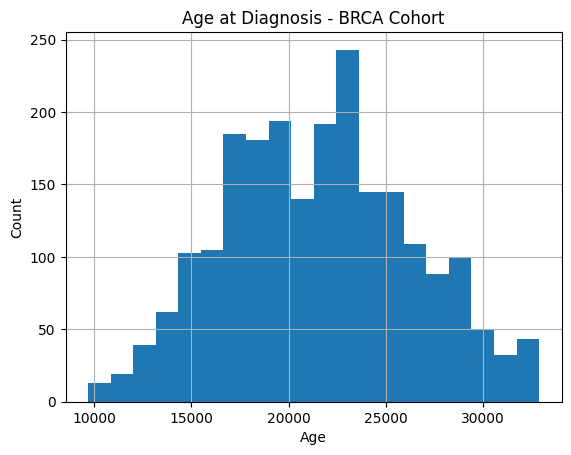

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Age distribution ---
merged_meta_df['onset_age_days'].dropna().hist(bins=20)
plt.title("Age at Diagnosis - BRCA Cohort")
plt.xlabel("Age"); plt.ylabel("Count")
plt.show()
mean(merged_meta_df['onset_age_days'])

<Axes: xlabel='sex_label_individual'>

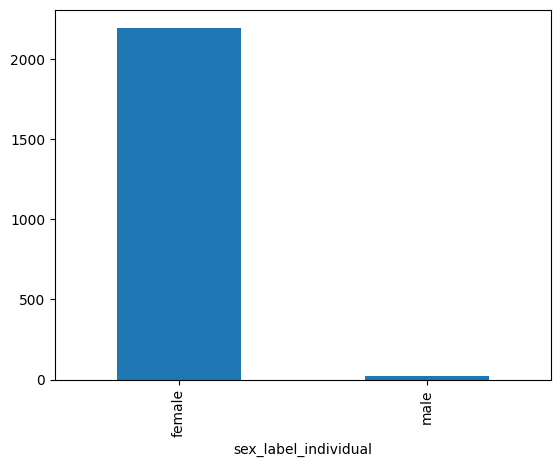

In [26]:
# --- Sex breakdown --
merged_meta_df['sex_label_individual'].value_counts().plot(kind='bar')

In [28]:
# --- Subtype/histology ---
merged_meta_df['histological_diagnosis_label'].value_counts().head(10)

histological_diagnosis_label
Unspecified Tissue                                       1115
Ductal Breast Carcinoma                                   785
Lobular Breast Carcinoma                                  203
Invasive Ductal and Invasive Lobular Breast Carcinoma      28
Breast Adenocarcinoma                                      26
Mucinous Adenocarcinoma                                    16
Metaplastic Breast Carcinoma                               16
Intraductal Papillary Adenocarcinoma with Invasion          6
Medullary Breast Carcinoma                                  6
Paget Disease of the Breast                                 3
Name: count, dtype: int64

In [30]:
# --- Summary stats ---
print(merged_meta_df[['onset_age_days', 'followup_days']].describe())

       onset_age_days  followup_days
count     2187.000000    2011.000000
mean     21557.021491    1167.314272
std       4805.568242    1167.053218
min       9704.000000       0.000000
25%      18016.000000     425.000000
50%      21518.000000     760.000000
75%      24844.500000    1551.000000
max      32870.000000    8577.000000


### Build Survival Outcome
Keep one biosample for each individual

In [31]:
survival_df = merged_meta_df.copy()

# Survival time
survival_df["time"] = pd.to_numeric(survival_df["followup_days"], errors="coerce")

def map_event(row):
    """
    Convert individual-level follow-up / vital status into a binary event label.
    0 = alive / censored
    1 = dead / event occurred
    """
    followup_state = str(row.get("followup_state_label", "")).strip().lower()
    vital_status = str(row.get("vital_status", "")).strip().upper()

    if "alive" in followup_state:
        return 0
    if "deceased" in followup_state or "dead" in followup_state:
        return 1

    if vital_status == "ALIVE":
        return 0
    if vital_status == "DECEASED":
        return 1

    return np.nan

survival_df["event"] = survival_df.apply(map_event, axis=1)

# Keep only rows with usable survival data
survival_df = survival_df.dropna(subset=["biosample_id", "individual_id", "time", "event"]).copy()
survival_df["event"] = survival_df["event"].astype(int)

print("Rows with usable survival data:", len(survival_df))
survival_df[[
    "biosample_id",
    "individual_id",
    "time",
    "event",
    "followup_state_label",
    "vital_status",
    "sex_label_individual"
]].head()

Rows with usable survival data: 2011


,biosample_id,individual_id,time,event,followup_state_label,vital_status,sex_label_individual
0,pgxbs-kftvi3zb,pgxind-kftx3mv9,456.0,0,alive (follow-up status),ALIVE,female
1,pgxbs-kftvhil5,pgxind-kftx3gi9,973.0,0,alive (follow-up status),ALIVE,female
2,pgxbs-kftvhnny,pgxind-kftx3m7z,425.0,0,alive (follow-up status),ALIVE,female
3,pgxbs-kftvhq2j,pgxind-kftx3oeo,2828.0,0,alive (follow-up status),ALIVE,female
4,pgxbs-kftvhkb9,pgxind-kftx3fa9,2281.0,0,alive (follow-up status),ALIVE,female


In [32]:
survival_unique_df = (
    survival_df
    .groupby("individual_id")
    .sample(n=1, random_state=42)   
    .copy()
)

print("Rows after keeping one biosample per individual:", len(survival_unique_df))
survival_unique_df[[
    "biosample_id",
    "individual_id",
    "sample_origin_type_label",
    "time",
    "event",
    "sex_label_individual"
]].head()

Rows after keeping one biosample per individual: 991


,biosample_id,individual_id,sample_origin_type_label,time,event,sex_label_individual
1259,pgxbs-kftvi0tx,pgxind-kftx3f7j,specimen from organism,1460.0,0,female
1127,pgxbs-kftvhsln,pgxind-kftx3f7p,specimen from organism,3011.0,0,female
1917,pgxbs-kftvhufy,pgxind-kftx3f9h,specimen from organism,1155.0,0,female
902,pgxbs-kftvhhju,pgxind-kftx3f9n,specimen from organism,425.0,0,female
296,pgxbs-kftvhhkd,pgxind-kftx3fa9,specimen from organism,2281.0,0,female


In [33]:
FINAL_META_COLUMNS = [
    # biosample-level
    "biosample_id",
    "individual_id",
    "biosample_name",
    "notes",
    "histological_diagnosis_id",
    "histological_diagnosis_label",
    "pathological_stage_id",
    "pathological_stage_label",
    "sample_origin_type_id",
    "sample_origin_type_label",
    "sampled_tissue_id",
    "sampled_tissue_label",
    "tcgaproject_id",
    "tcgaproject_label",
    "icdo_morphology_id",
    "icdo_topography_id",
    "icdo_topography_label",

    # individual-level
    "sex_id_individual",
    "sex_label_individual",
    "vital_status",
    "info_age_at_diagnosis_days",
    "info_days_to_death",
    "info_death",
    "info_ethnicity",
    "info_race",
    "info_year_of_birth",
    "tcga_case_id",
    "tcga_submitter_id",
    "disease_id",
    "disease_label",
    "followup_days",
    "followup_time_iso",
    "followup_state_id",
    "followup_state_label",
    "onset_age_iso",
    "onset_age_days",
    "stage_id_individual",
    "stage_label_individual",

    # derived survival variables
    "time",
    "event",
]

FINAL_META_COLUMNS = [c for c in FINAL_META_COLUMNS if c in survival_unique_df.columns]

survival_unique_df = survival_unique_df[FINAL_META_COLUMNS].copy()

print("Final survival metadata shape:", survival_unique_df.shape)
survival_unique_df.head()

Final survival metadata shape: (991, 40)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,followup_days,followup_time_iso,followup_state_id,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual,time,event
1259,pgxbs-kftvi0tx,pgxind-kftx3f7j,d9de9f71-2b39-4d21-9c93-8e199080c011,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,1460.0,P48M,EFO:0030041,alive (follow-up status),NaN,NaN,NCIT:C27968,Stage IIB,1460.0,0
1127,pgxbs-kftvhsln,pgxind-kftx3f7p,8cf391f9-d743-408f-8891-2c49db90907c,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,...,3011.0,P99M,EFO:0030041,alive (follow-up status),P51Y4M21D,18770.0,NCIT:C27977,Stage IIIA,3011.0,0
1917,pgxbs-kftvhufy,pgxind-kftx3f9h,6f8ec63c-a0f2-4b7f-bcd9-46725ca5b111,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,1155.0,P38M,EFO:0030041,alive (follow-up status),P66Y6M25D,24313.0,NCIT:C27968,Stage IIB,1155.0,0
902,pgxbs-kftvhhju,pgxind-kftx3f9n,41af42ec-7521-4783-916e-2c982eef0f98,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,425.0,P14M,EFO:0030041,alive (follow-up status),P55Y0M3D,20091.0,NCIT:C27968,Stage IIB,425.0,0
296,pgxbs-kftvhhkd,pgxind-kftx3fa9,a6cd09dc-ac7c-4bdc-9bb4-14f8cce6642d,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,2281.0,P75M,EFO:0030041,alive (follow-up status),P66Y5M20D,24278.0,NCIT:C27967,Stage IIA,2281.0,0


## Retrieve full CNV records and derive gene-level features locally

We use the record-level endpoint:

- retrieve all CNV records for each retained biosample,
- identify which CNV intervals overlap the target gene,
- and summarize those overlaps into simple binary features.

For the target gene, we define:

- `EGFR_hit`: at least one CNV overlaps the EGFR locus
- `EGFR_gain_hit`: at least one overlapping CNV is a gain
- `EGFR_loss_hit`: at least one overlapping CNV is a loss



In [73]:
TARGET_GENE = "MYC"

GENE_COORDS = {
    "MYC": {
        "chromosome": "8",
        "start": 127735434,
        "end": 127742951,
    }
}

gene_info = GENE_COORDS[TARGET_GENE]
print(TARGET_GENE, gene_info)

MYC {'chromosome': '8', 'start': 127735434, 'end': 127742951}


## Define helper functions

We now define helper functions to:

1. retrieve full CNV records for one biosample,
2. extract the record list from the Beacon response,
3. test whether a CNV interval overlaps the target gene,
4. classify the CNV state as gain or loss,
5. and summarize all records for one biosample into three binary gene-level features.

In [47]:
SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json, text/plain, */*",
})

def fetch_biosample_variants_record(biosample_id, session=SESSION, timeout=120):
    """
    Fetch all CNV variant records for one biosample from the
    biosample-scoped Progenetix g_variants endpoint.
    """
    url = f"https://progenetix.org/beacon/biosamples/{biosample_id}/g_variants/"
    params = {
        "requestedGranularity": "record"
    }
    response = session.get(url, params=params, timeout=timeout)
    response.raise_for_status()
    return response.json()

In [48]:
def extract_variant_results(data):
    # Extract the list of variant records from a Beacon JSON response.
    response = data.get("response", {})
    result_sets = response.get("resultSets", [])

    if not result_sets:
        return []

    return result_sets[0].get("results", [])

In [49]:
#helper functions for overlap and state parsing

def intervals_overlap(start1, end1, start2, end2):
    # Return True if two genomic intervals overlap.
    return (start1 <= end2) and (start2 <= end1)


def classify_copy_change(label):
    """
    Reduce CNV state labels into broader categories.

    Output categories:
    - gain
    - loss
    - other
    """
    if not isinstance(label, str):
        return "other"

    x = label.strip().lower()

    if "gain" in x or "high-level gain" in x or "low-level gain" in x:
        return "gain"
    if "loss" in x or "high-level loss" in x or "low-level loss" in x:
        return "loss"

    return "other"

## Summarize one biosample into EGFR-based binary features

For each biosample, we scan all returned CNV records and check:

- whether the record is on the same chromosome as EGFR,
- whether the CNV interval overlaps the EGFR locus,
- and whether the overlapping CNV is classified as gain or loss.

From this, we build three simple Boolean features:

- `EGFR_hit`
- `EGFR_gain_hit`
- `EGFR_loss_hit`

In [50]:
def summarize_gene_features_from_records(records, gene_name, gene_info):
    """
    Summarize all CNV records for one biosample into three binary features:
    - GENE_hit
    - GENE_gain_hit
    - GENE_loss_hit
    """
    gene_chr = str(gene_info["chromosome"])
    gene_start = int(gene_info["start"])
    gene_end = int(gene_info["end"])

    features = {
        f"{gene_name}_hit": 0,
        f"{gene_name}_gain_hit": 0,
        f"{gene_name}_loss_hit": 0,
    }

    for item in records:
        variation = item.get("variation", {})
        location = variation.get("location", {})

        chrom = str(location.get("chromosome"))
        start = location.get("start")
        end = location.get("end")

        if chrom != gene_chr:
            continue
        if start is None or end is None:
            continue

        if not intervals_overlap(start, end, gene_start, gene_end):
            continue

        # At least one overlapping CNV exists
        features[f"{gene_name}_hit"] = 1

        # Prefer copyChange, fallback to variantState.label
        state_label = variation.get("copyChange")
        if state_label is None:
            state_label = variation.get("variantState", {}).get("label")

        state = classify_copy_change(state_label)

        if state == "gain":
            features[f"{gene_name}_gain_hit"] = 1
        elif state == "loss":
            features[f"{gene_name}_loss_hit"] = 1

    return features

### Debug function to inspect one biosample

In [51]:
def inspect_gene_overlaps_for_one_biosample(biosample_id, gene_name, gene_info):
    # Debug helper: print overlapping CNV records for one biosample.

    data = fetch_biosample_variants_record(biosample_id)
    records = extract_variant_results(data)

    gene_chr = str(gene_info["chromosome"])
    gene_start = int(gene_info["start"])
    gene_end = int(gene_info["end"])

    overlaps = []

    for item in records:
        variation = item.get("variation", {})
        location = variation.get("location", {})

        chrom = str(location.get("chromosome"))
        start = location.get("start")
        end = location.get("end")

        if chrom != gene_chr:
            continue
        if start is None or end is None:
            continue
        if not intervals_overlap(start, end, gene_start, gene_end):
            continue

        overlaps.append({
            "chromosome": chrom,
            "start": start,
            "end": end,
            "copyChange": variation.get("copyChange"),
            "variantStateLabel": variation.get("variantState", {}).get("label"),
        })

    return pd.DataFrame(overlaps)

In [40]:
test_biosample_id = survival_unique_df["biosample_id"].iloc[0]
test = inspect_gene_overlaps_for_one_biosample(test_biosample_id, TARGET_GENE, gene_info)
test.shape

(0, 0)

## Build EGFR features for all retained biosamples

We now apply the same logic to all retained biosamples.

For each biosample, we:
- retrieve the full CNV record set once,
- derive EGFR overlap features locally,
- and store the results in a compact biosample-level feature table.

In [52]:
def build_gene_feature_table_from_records(biosample_ids, gene_name, gene_info):
    """
    Build a biosample-level feature table by querying full record data
    and summarizing gene overlap features locally.
    """
    rows = []
    failures = []

    for biosample_id in tqdm(biosample_ids, desc=f"Building {gene_name} features from record data"):
        try:
            data = fetch_biosample_variants_record(biosample_id)
            records = extract_variant_results(data)

            features = summarize_gene_features_from_records(records, gene_name, gene_info)
            features["biosample_id"] = biosample_id
            rows.append(features)

        except Exception as e:
            failures.append((biosample_id, str(e)))
            rows.append({
                "biosample_id": biosample_id,
                f"{gene_name}_hit": np.nan,
                f"{gene_name}_gain_hit": np.nan,
                f"{gene_name}_loss_hit": np.nan,
            })

    feature_df = pd.DataFrame(rows)
    return feature_df, failures

In [53]:
biosample_ids_for_features = survival_unique_df["biosample_id"].dropna().astype(str).tolist()

gene_feature_df, gene_feature_failures = build_gene_feature_table_from_records(
    biosample_ids=biosample_ids_for_features,
    gene_name=TARGET_GENE,
    gene_info=gene_info
)

print("Feature table shape:", gene_feature_df.shape)
print("Number of failed biosample queries:", len(gene_feature_failures))
gene_feature_df.head()

Building MYC features from record data: 100%|██████████| 991/991 [24:43<00:00,  1.50s/it]  

Feature table shape: (991, 4)
Number of failed biosample queries: 0


,MYC_hit,MYC_gain_hit,MYC_loss_hit,biosample_id
0,1,0,1,pgxbs-kftvi0tx
1,1,1,1,pgxbs-kftvhsln
2,0,0,0,pgxbs-kftvhufy
3,1,1,0,pgxbs-kftvhhju
4,1,1,1,pgxbs-kftvhhkd


In [54]:
# inspect failures if needed 

if len(gene_feature_failures) > 0:
    print("Example failures:")
    print(gene_feature_failures[:10])
else:
    print("No failures detected.")

No failures detected.


## Merge EGFR features into the survival metadata

We now merge the EGFR-derived biosample features back into the survival metadata table.

This gives us a final analysis table containing:

- one retained biosample per individual,
- survival time,
- event status,
- and the three EGFR-based CNV features.

In [55]:
analysis_df = survival_unique_df.merge(
    gene_feature_df,
    on="biosample_id",
    how="left"
)

feature_cols = [
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]

analysis_df[feature_cols] = analysis_df[feature_cols].fillna(0).astype(int)

print("Analysis table shape:", analysis_df.shape)
analysis_df.head()

Analysis table shape: (991, 43)


,biosample_id,individual_id,biosample_name,notes,histological_diagnosis_id,histological_diagnosis_label,pathological_stage_id,pathological_stage_label,sample_origin_type_id,sample_origin_type_label,...,followup_state_label,onset_age_iso,onset_age_days,stage_id_individual,stage_label_individual,time,event,MYC_hit,MYC_gain_hit,MYC_loss_hit
0,pgxbs-kftvi0tx,pgxind-kftx3f7j,d9de9f71-2b39-4d21-9c93-8e199080c011,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,alive (follow-up status),NaN,NaN,NCIT:C27968,Stage IIB,1460.0,0,1,0,1
1,pgxbs-kftvhsln,pgxind-kftx3f7p,8cf391f9-d743-408f-8891-2c49db90907c,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27977,Stage IIIA,OBI:0001479,specimen from organism,...,alive (follow-up status),P51Y4M21D,18770.0,NCIT:C27977,Stage IIIA,3011.0,0,1,1,1
2,pgxbs-kftvhufy,pgxind-kftx3f9h,6f8ec63c-a0f2-4b7f-bcd9-46725ca5b111,Blood Derived Normal,NCIT:C132256,Unspecified Tissue,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,alive (follow-up status),P66Y6M25D,24313.0,NCIT:C27968,Stage IIB,1155.0,0,0,0,0
3,pgxbs-kftvhhju,pgxind-kftx3f9n,41af42ec-7521-4783-916e-2c982eef0f98,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27968,Stage IIB,OBI:0001479,specimen from organism,...,alive (follow-up status),P55Y0M3D,20091.0,NCIT:C27968,Stage IIB,425.0,0,1,1,0
4,pgxbs-kftvhhkd,pgxind-kftx3fa9,a6cd09dc-ac7c-4bdc-9bb4-14f8cce6642d,Primary Tumor,NCIT:C4017,Ductal Breast Carcinoma,NCIT:C27967,Stage IIA,OBI:0001479,specimen from organism,...,alive (follow-up status),P66Y5M20D,24278.0,NCIT:C27967,Stage IIA,2281.0,0,1,1,1


In [56]:
# check for feature distribution
for col in feature_cols:
    print(f"\n{col}")
    print(analysis_df[col].value_counts(dropna=False))


MYC_hit
MYC_hit
1    589
0    402
Name: count, dtype: int64

MYC_gain_hit
MYC_gain_hit
0    626
1    365
Name: count, dtype: int64

MYC_loss_hit
MYC_loss_hit
0    502
1    489
Name: count, dtype: int64


In [57]:
# final data
FINAL_ANALYSIS_COLUMNS = [
    "biosample_id",
    "individual_id",
    "histological_diagnosis_label",
    "tcgaproject_label",
    "sample_origin_type_label",
    "sex_label_individual",
    "stage_label_individual",
    "followup_days",
    "followup_time_iso",
    "followup_state_label",
    "vital_status",
    "time",
    "event",
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]

FINAL_ANALYSIS_COLUMNS = [c for c in FINAL_ANALYSIS_COLUMNS if c in analysis_df.columns]
analysis_df = analysis_df[FINAL_ANALYSIS_COLUMNS].copy()

analysis_df.head()

,biosample_id,individual_id,histological_diagnosis_label,tcgaproject_label,sample_origin_type_label,sex_label_individual,stage_label_individual,followup_days,followup_time_iso,followup_state_label,vital_status,time,event,MYC_hit,MYC_gain_hit,MYC_loss_hit
0,pgxbs-kftvi0tx,pgxind-kftx3f7j,Ductal Breast Carcinoma,Breast invasive carcinoma,specimen from organism,female,Stage IIB,1460.0,P48M,alive (follow-up status),ALIVE,1460.0,0,1,0,1
1,pgxbs-kftvhsln,pgxind-kftx3f7p,Ductal Breast Carcinoma,Breast invasive carcinoma,specimen from organism,female,Stage IIIA,3011.0,P99M,alive (follow-up status),ALIVE,3011.0,0,1,1,1
2,pgxbs-kftvhufy,pgxind-kftx3f9h,Unspecified Tissue,Breast invasive carcinoma,specimen from organism,female,Stage IIB,1155.0,P38M,alive (follow-up status),ALIVE,1155.0,0,0,0,0
3,pgxbs-kftvhhju,pgxind-kftx3f9n,Ductal Breast Carcinoma,Breast invasive carcinoma,specimen from organism,female,Stage IIB,425.0,P14M,alive (follow-up status),ALIVE,425.0,0,1,1,0
4,pgxbs-kftvhhkd,pgxind-kftx3fa9,Ductal Breast Carcinoma,Breast invasive carcinoma,specimen from organism,female,Stage IIA,2281.0,P75M,alive (follow-up status),ALIVE,2281.0,0,1,1,1


## Kaplan–Meier survival analysis

We first use Kaplan–Meier curves to compare survival between groups.

It directly estimates survival probability over time for different groups.

Here we use one Boolean gene-level CNV feature to define the groups, for example:

- `EGFR_hit = 1` versus `EGFR_hit = 0`
- or `EGFR_gain_hit = 1` versus `EGFR_gain_hit = 0`
- or `EGFR_loss_hit = 1` versus `EGFR_loss_hit = 0`

This provides a visual first impression of whether the feature may be associated with different survival patterns.

try EGFR_gain_hit

In [58]:
KM_FEATURE = f"{TARGET_GENE}_gain_hit"
print("Kaplan–Meier grouping feature:", KM_FEATURE)

analysis_df[[KM_FEATURE, "time", "event"]].head()

Kaplan–Meier grouping feature: MYC_gain_hit


,MYC_gain_hit,time,event
0,0,1460.0,0
1,1,3011.0,0
2,0,1155.0,0
3,1,425.0,0
4,1,2281.0,0


## Plot Kaplan–Meier curves

We now divide the samples into two groups based on the selected feature:

- group 0: feature absent
- group 1: feature present

We then estimate and plot survival curves for both groups.

In [59]:
group_0 = analysis_df[analysis_df[KM_FEATURE] == 0].copy()
group_1 = analysis_df[analysis_df[KM_FEATURE] == 1].copy()

print("Group sizes")
print("-----------")
print(f"{KM_FEATURE} = 0 :", len(group_0))
print(f"{KM_FEATURE} = 1 :", len(group_1))

Group sizes
-----------
MYC_gain_hit = 0 : 626
MYC_gain_hit = 1 : 365


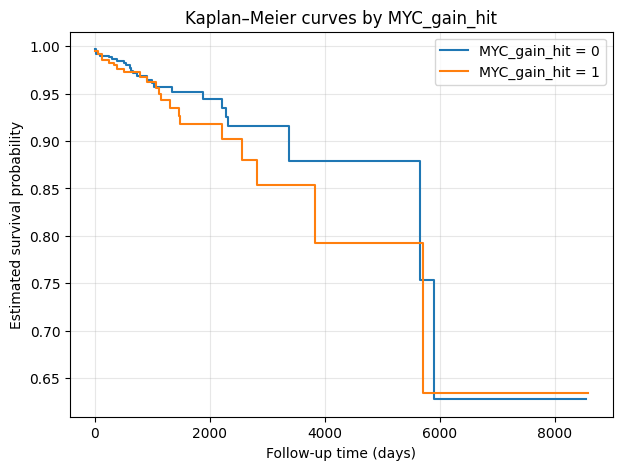

In [60]:
plt.figure(figsize=(7, 5))

for group_df, label in [
    (group_0, f"{KM_FEATURE} = 0"),
    (group_1, f"{KM_FEATURE} = 1"),
]:
    if len(group_df) == 0:
        continue

    time, survival_prob = kaplan_meier_estimator(
        event=group_df["event"].astype(bool),
        time_exit=group_df["time"].astype(float),
    )

    plt.step(time, survival_prob, where="post", label=label)

plt.xlabel("Follow-up time (days)")
plt.ylabel("Estimated survival probability")
plt.title(f"Kaplan–Meier curves by {KM_FEATURE}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Plot KM for any feature

In [61]:
def plot_km_for_feature(df, feature_col, title=None):
    # Plot Kaplan–Meier curves for a binary feature column.
    
    plt.figure(figsize=(7, 5))

    for value in [0, 1]:
        group_df = df[df[feature_col] == value].copy()
        if len(group_df) == 0:
            continue

        time, survival_prob = kaplan_meier_estimator(
            event=group_df["event"].astype(bool),
            time_exit=group_df["time"].astype(float),
        )

        plt.step(time, survival_prob, where="post", label=f"{feature_col} = {value}")

    plt.xlabel("Follow-up time (days)")
    plt.ylabel("Estimated survival probability")
    plt.title(title if title is not None else f"Kaplan–Meier curves by {feature_col}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

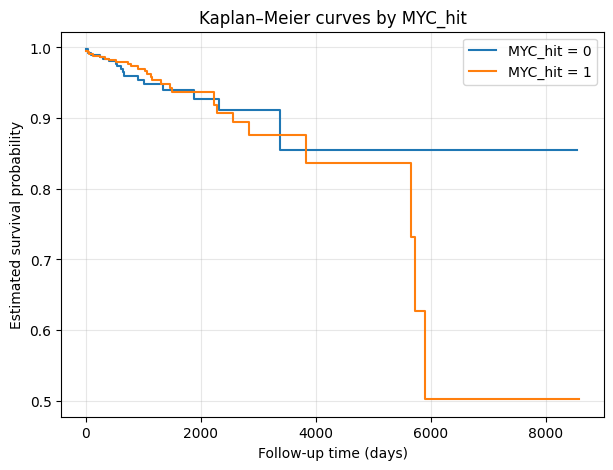

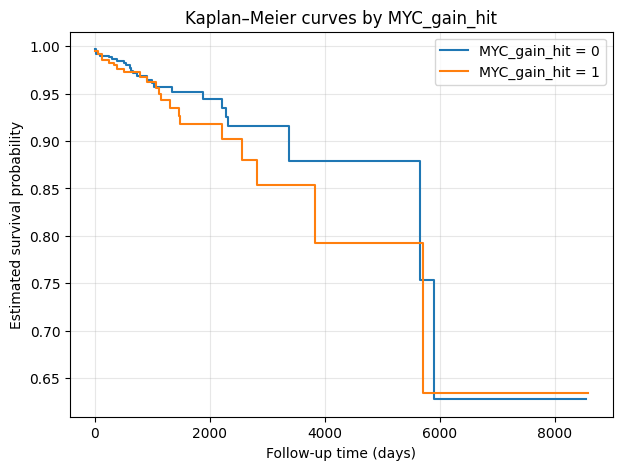

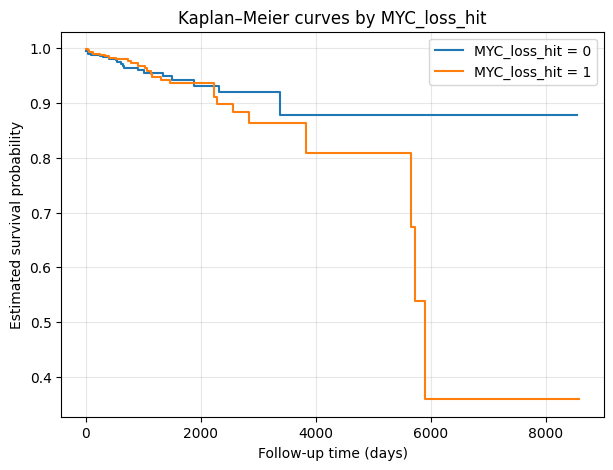

In [62]:
for feature_col in [
    f"{TARGET_GENE}_hit",
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
]:
    plot_km_for_feature(analysis_df, feature_col)

## Cox proportional hazards model

Kaplan–Meier curves are useful for visual comparison, but they do not provide a regression-based estimate of effect size.

We therefore also fit a Cox proportional hazards model.

The Cox model estimates how each feature is associated with hazard over time.  
The fitted coefficient can be interpreted as follows:

- positive coefficient → higher hazard
- negative coefficient → lower hazard

If we exponentiate the coefficient, we obtain a **hazard ratio**.

## Choose Cox model covariates

We begin with:

- one Boolean CNV feature for the target gene,
- and optionally one covariate such as sex.


In [67]:
# 1. Start fresh from analysis_df
cox_df = analysis_df.copy()

# 2. Encode sex
cox_df["sex_binary"] = (
    cox_df["sex_label_individual"]
    .astype(str).str.strip().str.lower()
    .map({"female": 0, "male": 1})
)

# 3. Encode stage — on the SAME cox_df
stage_map = {
    "Stage I": 1, "Stage IA": 1, "Stage IB": 1,
    "Stage II": 2, "Stage IIA": 2, "Stage IIB": 2,
    "Stage III": 3, "Stage IIIA": 3, "Stage IIIB": 3, "Stage IIIC": 3,
    "Stage IV": 4,
    "Stage Unknown": np.nan,
}
cox_df["stage_numeric"] = (
    cox_df["stage_label_individual"]
    .astype(str).str.strip()
    .map(stage_map)
)

# 4. Verify before fitting
print(cox_df["stage_numeric"].value_counts(dropna=False))
print(cox_df[["time", "event"] + COX_FEATURES].isna().sum())

stage_numeric
2.0    577
3.0    220
1.0    168
NaN     15
4.0     11
Name: count, dtype: int64
time            0
event           0
MYC_gain_hit    0
MYC_loss_hit    0
sex_binary      0
dtype: int64


In [68]:
COX_FEATURES = [
    f"{TARGET_GENE}_gain_hit",
    f"{TARGET_GENE}_loss_hit",
    "sex_binary",
    "stage_numeric",      # <-- add this
]

cox_model_df = cox_df.dropna(subset=["time", "event"] + COX_FEATURES).copy()

X = cox_model_df[COX_FEATURES].astype(float).copy()

y = Surv.from_arrays(
    event=cox_model_df["event"].astype(bool),
    time=cox_model_df["time"].astype(float),
)

cox_model = CoxPHSurvivalAnalysis()
cox_model.fit(X, y)

coef_df = pd.DataFrame({
    "feature": COX_FEATURES,
    "coefficient": cox_model.coef_,
    "hazard_ratio": np.exp(cox_model.coef_),
})

coef_df

,feature,coefficient,hazard_ratio
0,MYC_gain_hit,0.443815,1.558642
1,MYC_loss_hit,0.006171,1.006190
2,sex_binary,0.357509,1.429764
3,stage_numeric,1.110018,3.034412


## Visualize Cox model results

The Cox model coefficients can be transformed into hazard ratios by exponentiation.

In the plot below:

- a hazard ratio of **1** indicates no association,
- values **greater than 1** indicate higher hazard,
- values **less than 1** indicate lower hazard.


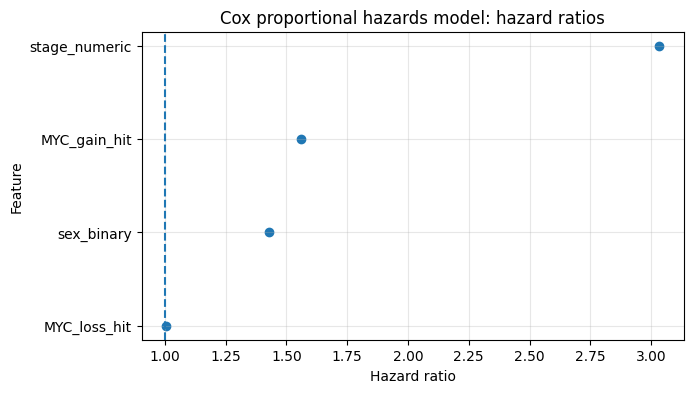

In [72]:
plt.figure(figsize=(7, 4))

plot_df = coef_df.sort_values("hazard_ratio").reset_index(drop=True)
y_pos = np.arange(len(plot_df))

plt.scatter(plot_df["hazard_ratio"], y_pos)
plt.axvline(1.0, linestyle="--")

plt.yticks(y_pos, plot_df["feature"])
plt.xlabel("Hazard ratio")
plt.ylabel("Feature")
plt.title("Cox proportional hazards model: hazard ratios")
plt.grid(alpha=0.3)
plt.show()

## Concordance index

The concordance index (C-index) measures how well the Cox model ranks samples by risk.

It can be interpreted as a survival-specific ranking metric:

- **0.5** means the model performs no better than random ranking,
- values **closer to 1** indicate better discrimination,
- and values **below 0.5** suggest that the model ranks risk poorly.

Importantly, the C-index is not the same as classification accuracy.  
It evaluates whether samples predicted to be at higher risk tend to experience the event earlier.

In [71]:
# calculate concordance index

risk_scores = cox_model.predict(X)

cindex = concordance_index_censored(
    event_indicator=cox_model_df["event"].astype(bool),
    event_time=cox_model_df["time"].astype(float),
    estimate=risk_scores,
)

print("Concordance index:", cindex[0])

Concordance index: 0.6951599207472403


The concordance index is approximately **0.60**.

This suggests that the Cox model has **modest discriminatory ability**:
it performs better than random ranking, but the predictive signal is still limited.

This is not surprising in the current notebook, because the model is intentionally simple and uses only a small number of interpretable features.  

## Summary


This survival analysis notebook shows how to move from:

1. biosample-level metadata,
2. to individual-level follow-up information,
3. to biosample-level CNV records,
4. to gene-level Boolean features,
5. and finally to survival analysis.